# Определение возраста покупателей по фотографии

# Исследовательский анализ данных

Сетевой супермаркет «Хлеб-Соль» внедряет систему компьютерного зрения для обработки фотографий покупателей. Фотофиксация в прикассовой зоне поможет определять возраст клиентов

<h1>Содержание<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#Описание-проекта" data-toc-modified-id="Описание-проекта-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>Описание проекта</a></span></li><li><span><a href="#Импорт-данных-и-разведочный-анализ" data-toc-modified-id="Импорт-данных-и-разведочный-анализ-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>Импорт данных и разведочный анализ</a></span><ul class="toc-item"><li><span><a href="#Вывод" data-toc-modified-id="Вывод-2.1"><span class="toc-item-num">2.1&nbsp;&nbsp;</span>Вывод</a></span></li></ul></li><li><span><a href="#Исследовательский-анализ" data-toc-modified-id="Исследовательский-анализ-3"><span class="toc-item-num">3&nbsp;&nbsp;</span>Исследовательский анализ</a></span><ul class="toc-item"><li><span><a href="#Целевой-признак-real_age" data-toc-modified-id="Целевой-признак-real_age-3.1"><span class="toc-item-num">3.1&nbsp;&nbsp;</span>Целевой признак <code>real_age</code></a></span></li><li><span><a href="#Изображения-file_name" data-toc-modified-id="Изображения-file_name-3.2"><span class="toc-item-num">3.2&nbsp;&nbsp;</span>Изображения <code>file_name</code></a></span></li><li><span><a href="#Вывод" data-toc-modified-id="Вывод-3.3"><span class="toc-item-num">3.3&nbsp;&nbsp;</span>Вывод</a></span></li></ul></li><li><span><a href="#Модель-предсказания-возраста-покупателей" data-toc-modified-id="Модель-предсказания-возраста-покупателей-4"><span class="toc-item-num">4&nbsp;&nbsp;</span>Модель предсказания возраста покупателей</a></span><ul class="toc-item"><li><span><a href="#Обучение-модели" data-toc-modified-id="Обучение-модели-4.1"><span class="toc-item-num">4.1&nbsp;&nbsp;</span>Обучение модели</a></span></li><li><span><a href="#Анализ-обученной-модели" data-toc-modified-id="Анализ-обученной-модели-4.2"><span class="toc-item-num">4.2&nbsp;&nbsp;</span>Анализ обученной модели</a></span></li></ul></li><li><span><a href="#Общий-вывод" data-toc-modified-id="Общий-вывод-5"><span class="toc-item-num">5&nbsp;&nbsp;</span>Общий вывод</a></span></li></ul></div>

## Описание проекта

**Заказчик**

Сетевой супермаркет «Хлеб-Соль»


**Входные данные**

Пул фотографий покупателей разных возрастов и таблица соответствия возраста и фотографии


**Задача**

Провести анализ данных и построить модель, которая по фотографии определит приблизительный возраст человека


**Цель**

Анализировать покупки и предлагать товары, которые могут заинтересовать покупателей этой возрастной группы. Контролировать добросовестность кассиров при продаже алкоголя

**Описание входных данных**

- `/final_files` - папка с изобажениями покупателей
- `labels.csv` - таблица соответствия возраста и фотографии покупателей

In [1]:
# загрузка библиотек
!pip install numba==0.57.1 -q
!pip install pingouin -q
!pip install --upgrade seaborn -q

In [49]:
# стандартные библиотеки
import pandas as pd
import numpy as np
import warnings
import random

# графики и изображения
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from PIL import Image

# статистика
from scipy.stats import kstest

# МО
from tensorflow.keras.applications import InceptionResNetV2
from tensorflow.keras.layers import (
    Dense, 
    GlobalAveragePooling2D, 
    Dropout)
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# дополнительные библиотеки
import pingouin as pg

# константы
RANDOM_STATE=42
SEED=42
random.seed(42)
np.random.seed(42)
warnings.filterwarnings("ignore")

## Импорт данных и разведочный анализ

In [12]:
df = pd.read_csv('/datasets/faces/labels.csv')
print('Сводная информация по изначальным данным \n')
df.info()
print('\n Первые записи таблицы')
display(df.head())
print('\n Полных дубликатов - ', df.duplicated().sum())
print('\n Дубликатов в признаке file_name - ', df['file_name'].duplicated().sum())

Сводная информация по изначальным данным 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7591 entries, 0 to 7590
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   file_name  7591 non-null   object
 1   real_age   7591 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 118.7+ KB

 Первые записи таблицы


,file_name,real_age
0,000000.jpg,4
1,000001.jpg,18
2,000002.jpg,80
3,000003.jpg,50
4,000004.jpg,17



 Полных дубликатов -  0

 Дубликатов в признаке file_name -  0


### Вывод

Отлично, загрузили номера изображений и целевой признак - возраст
- 7591 объект
- Пропусков нет
- Дубликатов полных и неявных нет

## Исследовательский анализ

### Целевой признак `real_age`

Посмотрим на распределение возрастов

Статистика по возрасту


,count,mean,std,min,25%,50%,75%,max
real_age,7591.0,31.201159,17.14506,1.0,20.0,29.0,41.0,100.0


Тест Колмогорова-Смирнова на нормальность, p-value -  0.0


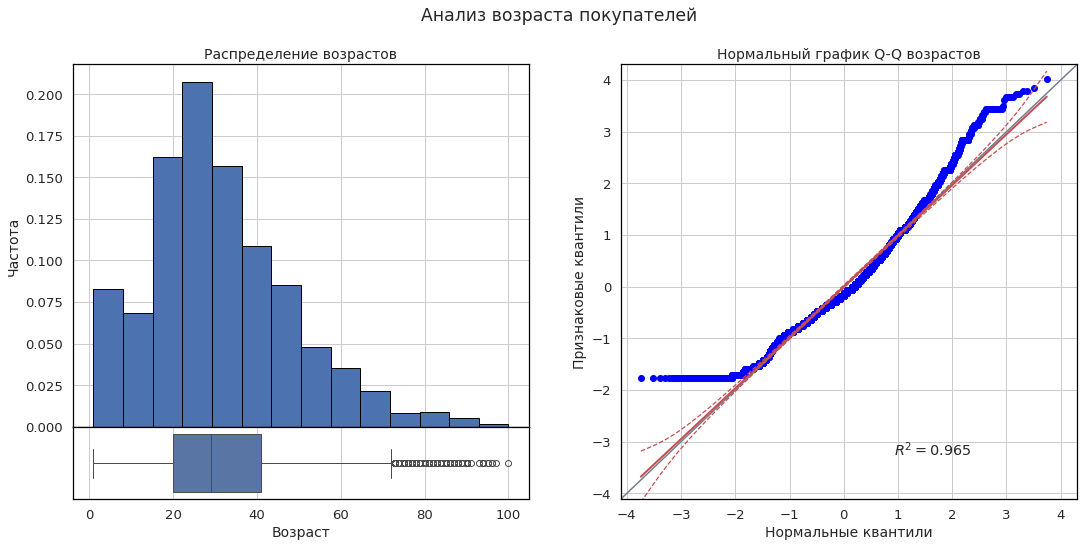

In [13]:
sns.set(font_scale=1.2)
sns.set_style('whitegrid', {'axes.edgecolor': 'black'})

print('Статистика по возрасту')
display(pd.DataFrame(df['real_age'].describe()).T)

fig = plt.figure(figsize=(18, 8))
gs = gridspec.GridSpec(2, 2, height_ratios=[5, 1])
gs.update(hspace=0)
ax_hist = plt.subplot(gs[0, 0])
ax_box = plt.subplot(gs[1, 0])
ax_qq = plt.subplot(gs[:, 1])

# Boxplot и гистограмма
sns.boxplot(x=df['real_age'], ax=ax_box)
sns.histplot(x=df['real_age'],
             bins='sturges',
             alpha=None,
             edgecolor='black',
             ax=ax_hist,
             stat='probability')
plt.subplots_adjust(hspace=0)

ax_box.set_xlabel('Возраст', size=14)
ax_hist.set_ylabel('Частота', size=14)
ax_hist.set_title(f'Распределение возрастов', size=14)

# QQ-plot
pg.qqplot(df['real_age'], ax=ax_qq, square=False)
ax_qq.set_title(f'Нормальный график Q-Q возрастов', size=14)
ax_qq.set_xlabel('Нормальные квантили', size=14)
ax_qq.set_ylabel('Признаковые квантили', size=14)
plt.suptitle('Анализ возраста покупателей')
print('Тест Колмогорова-Смирнова на нормальность, p-value - ', kstest(df['real_age'], 'norm').pvalue)

- Распределение по возрастам нормальное (p < 0.001) со смещением влево, в следствие что дети реже ходят в магазин
- Минимальный возраст - 1, возможно кто-то на кассе был с грудным ребенком, но все же это странно, надо дополнительно проверить
- Так же подозрительно выглядят покупатели с возрастом более 90 лет, хотя для выборки могли подобрать и такие уникальные случаи
- Медианный возраст - 29 лет

### Изображения `file_name`

Посмотрим на изображения с подозрительным возрастом

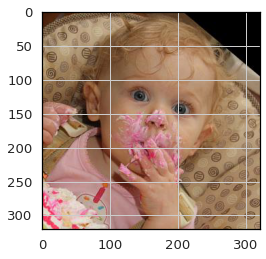

In [6]:
image = Image.open(f'/datasets/faces/final_files/{df["file_name"][df["real_age"].idxmin()]}')
plt.imshow(np.array(image));

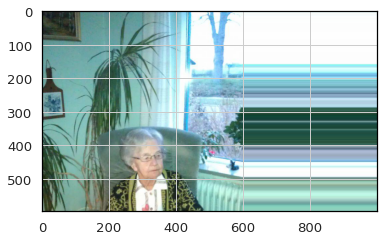

In [7]:
image = Image.open(f'/datasets/faces/final_files/{df["file_name"][df["real_age"].idxmax()]}')
plt.imshow(np.array(image));

- Фотографии потенциальных покупателей, но не на кассе :) Теперь понятно такое распределение по возрастам
- У изображений разный размер, есть признаки использования методов аугментации, например на последнем изображении свдиг или уавеличение по ширине с заполнением
- Сам покупатель может занимать малый процент изображения, поэтому выберем разрешение для загрузчика 512*512

Создадим потоковый загрузчик и посмотрим на примеры встречающхся изображений

In [45]:
sample = df.sample(n=128, random_state=RANDOM_STATE)
sample_datagen = ImageDataGenerator(rescale=1/255.)
sample_flow = sample_datagen.flow_from_dataframe(sample,
                                                 directory='/datasets/faces/final_files',
                                                 x_col='file_name',
                                                 y_col='real_age',
                                                 target_size=(256, 256),
                                                 batch_size=32,
                                                 class_mode='raw',
                                                 seed=SEED)

Found 128 validated image filenames.


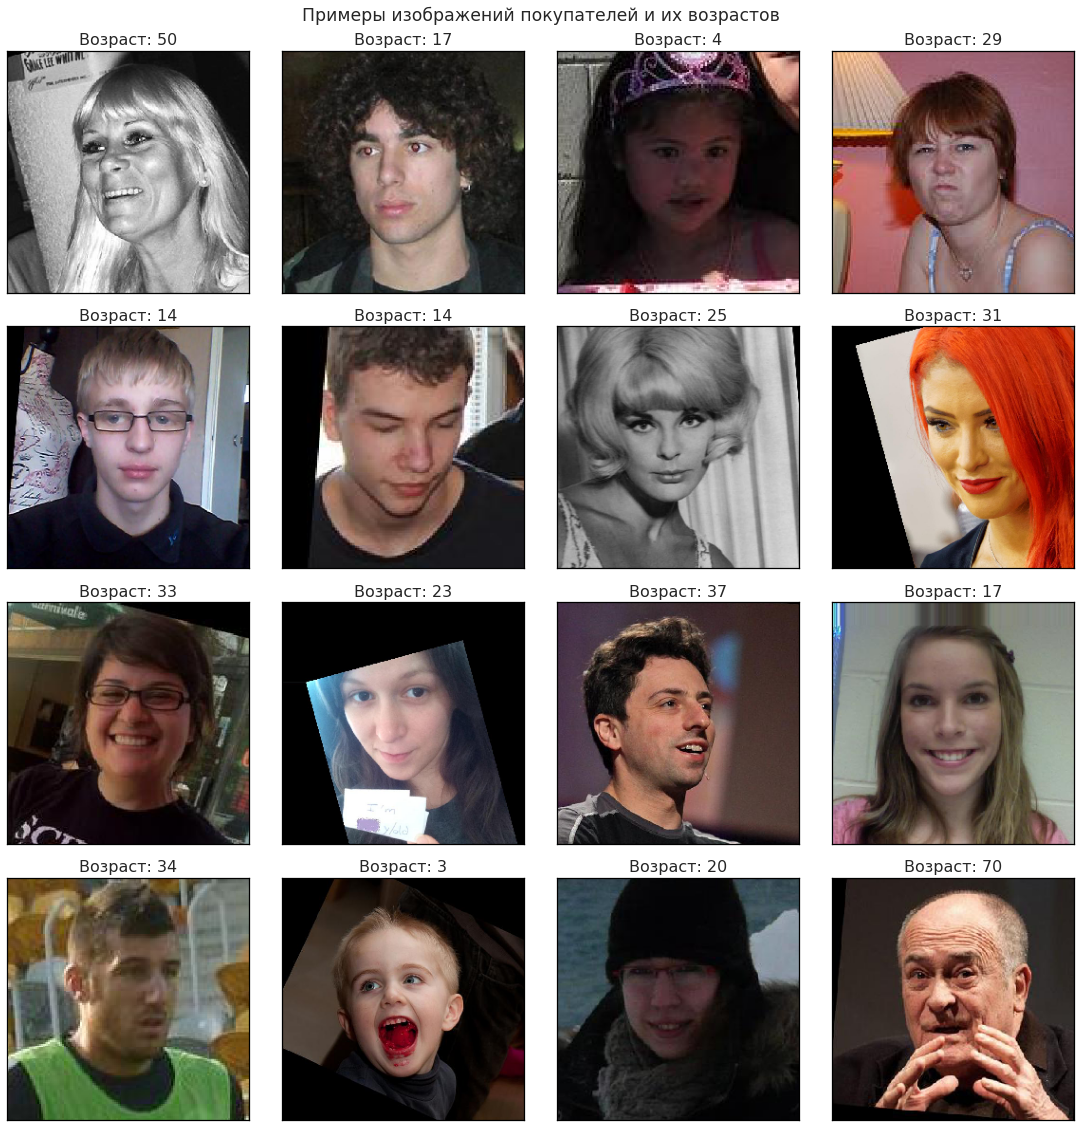

In [50]:
sample_features, sample_target = next(sample_flow)
fig = plt.figure(figsize=(16, 16))
plt.suptitle('Примеры изображений покупателей и их возрастов')
for i in range(16):
    fig.add_subplot(4, 4, i+1)
    plt.imshow(sample_features[i])
    plt.xticks([])
    plt.yticks([])
    plt.title(f'Возраст: {sample_target[i]}', fontsize=16)
    plt.tight_layout()

- Еще раз убеждаемся, что в датасете были использованы методы аугментации - повороты, в добавление к сдвигам, причем при повороте не использовалось заполнение
- Присутствуют как цветные так и чб изображения и разное освещение, а в магазине оно будет относительно стабильным
- Не всегда человек смотрит в кадр
- Разный фон, тогда как в магазине фон будет более менее постоянным
- Разная четкость изображений, тогда как в магазине она опять же будет более менее посоятнной

### Вывод

- Возраст
    - Распределение по возрастам нормальное (p < 0.001) со смещением влево, почти соответствует реальному
    - Минимальный возраст - 1, максимальный - 100 - данные не ограничены реальными условиями по возрасту для задачи
    - Медианный возраст - 29 лет


- Изображения
    - Использваны методы аугментации - повороты, увеличения размеров, заполнение
    - Различные внешние условия - освещенность, контрастность, цвет, четкость, фон
    - Разное разрешение
    - Так как большая часть преобразований аугментации уже присутствует в датасете, добавим только отражение по горизонтали, что позволит кратно увеличить выборку с учетом уже существующих методов аугментации


- Нестабильность внешних условий на изображениях скажется на результатах модели:
    - На тестовой выборке и в боевых условиях показатели модели будут хуже
    - Большая часть весов окажется бесполезной, что приведет к ухудшению метрики на деплое (угол съемки например, освещенность и другие признаки, которые уйдут в веса)
    - Неограниченность по возрасту так же создаст проблемы
    - В конечном итоге модель будет "недообученной" для нашей задачи, но со временем, когда наберется база снимков покупателей можно будет переобучить модель и повысить ее показатели
    - Из-за избытка параметров модель будет работать обучаться и предсказывать дольше по времени, чем могла бы на хороших данных

## Модель предсказания возраста покупателей

### Обучение модели

Создадим функции для обучения модели

```python
def load_train(path):
    
    train_datagen = ImageDataGenerator(validation_split=0.25, 
                                       rescale=1/255.,
                                       horizontal_flip=True)
    
    train_datagen_flow = train_datagen.flow_from_dataframe(
        dataframe=pd.read_csv(path + 'labels.csv'),
        directory=(path + '/final_files'),
        x_col='file_name',
        y_col='real_age',
        target_size=(299, 299),
        batch_size=32,
        class_mode='raw',
        subset='training',
        shuffle=True,
        seed=SEED)

    return train_datagen_flow

def load_test(path):
    
    test_datagen = ImageDataGenerator(validation_split=0.25, 
                                      rescale=1/255.)
    
    test_datagen_flow = test_datagen.flow_from_dataframe(
        dataframe=pd.read_csv(path + 'labels.csv'),
        directory=(path + '/final_files'),
        x_col='file_name',
        y_col='real_age',
        target_size=(299, 299),
        batch_size=32,
        class_mode='raw',
        subset='validation',
        shuffle=False,
        seed=SEED)

    return test_datagen_flow


def create_model(input_shape):
    optimizer = Adam(lr=0.0001)
    
    backbone = InceptionResNetV2(input_shape=(None, 299, 299, 3),
                        weights='imagenet',
                        include_top=False)

    model = Sequential()   
    model.add(backbone)
    model.add(GlobalAveragePooling2D())
    model.add(Dropout(0.3))
    model.add(Dense(512, activation='relu'))
    model.add(Dropout(0.3))    
    model.add(Dense(1, activation='relu'))
    
    model.compile(optimizer=optimizer, loss='mse',
                  metrics=['mae'])
    
    model.summary()
    
    return model

def train_model(model, train_data, test_data, batch_size=None, epochs=10,
                steps_per_epoch=None, validation_steps=None):

    model.fit(train_data, 
              validation_data=test_data,
              batch_size=batch_size, 
              epochs=epochs,
              steps_per_epoch=steps_per_epoch,
              validation_steps=validation_steps,
              verbose=2, 
              shuffle=True)

    return model
```

Результат обучения модели и ее валидации

```
Found 5694 validated image filenames.
Found 1897 validated image filenames.

178/178 - 131s - loss: 213.2264 - mae: 10.2863 - val_loss: 78.3032 - val_mae: 6.9644
Epoch 2/10
178/178 - 86s - loss: 59.1748 - mae: 5.8370 - val_loss: 63.4124 - val_mae: 5.9176
Epoch 3/10
178/178 - 84s - loss: 38.9659 - mae: 4.7477 - val_loss: 62.5155 - val_mae: 6.0726
Epoch 4/10
178/178 - 87s - loss: 30.9164 - mae: 4.2683 - val_loss: 66.7675 - val_mae: 6.1225
Epoch 5/10
178/178 - 89s - loss: 26.4951 - mae: 3.9754 - val_loss: 58.9315 - val_mae: 5.7492
Epoch 6/10
178/178 - 87s - loss: 23.3466 - mae: 3.7348 - val_loss: 62.4529 - val_mae: 5.9309
Epoch 7/10
178/178 - 90s - loss: 21.3732 - mae: 3.5849 - val_loss: 71.2039 - val_mae: 6.6270
Epoch 8/10
178/178 - 89s - loss: 18.6361 - mae: 3.3112 - val_loss: 61.7041 - val_mae: 6.0578
Epoch 9/10
178/178 - 86s - loss: 16.4183 - mae: 3.0934 - val_loss: 54.9072 - val_mae: 5.5311
Epoch 10/10
178/178 - 89s - loss: 14.5690 - mae: 2.8737 - val_loss: 54.2730 - val_mae: 5.4631

60/60 - 14s - loss: 54.2730 - mae: 5.4631
Test MAE: 5.4631
```

Отлично, целевая метрика MAE достигнута - **5.463** и модель показала отличные результаты

### Анализ обученной модели

Модель имеет следующую структуру и количество параметров

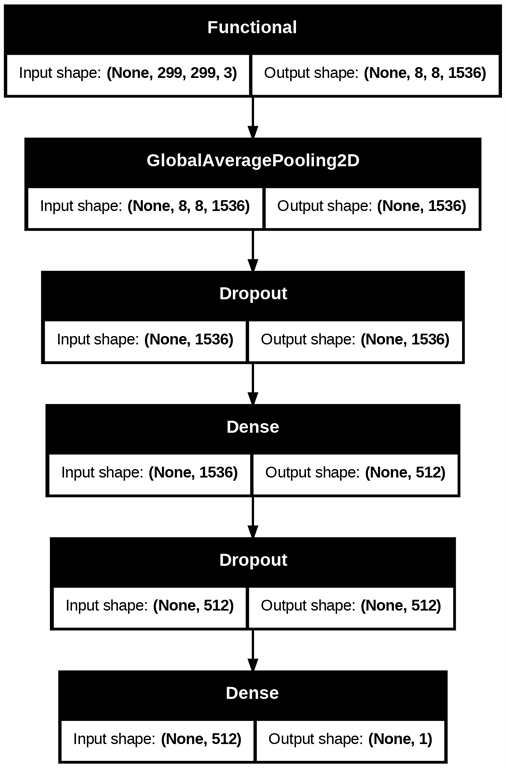

```
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ inception_resnet_v2 (Functional)     │ (None, 8, 8, 1536)          │      54,336,736 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 1536)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 1536)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 512)                 │         786,944 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             513 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘
 Total params: 55,124,193
 Trainable params: 55,063,649
 Non-trainable params: 60,544
```

- Общее количество параметров - 55 млн
- Размер батча - 32
- Количество эпох 10
- Оптимизатор Adam, learning_rate - 0.0001
- Входные изображения загрузчиком преобразовывались к разрешению 299x299, на котором обучалась InceptionResNetV2
- Метрика MAE модели - **5.463** близка к метрике авторов указанной в задании статьи
- Обучение на GPU Tesla занимает небольшое время
- Использование дополнительных аугментаций, кроме горизонтального отображения не привело к улучшению качества
- Использование Dropoutов помогло снизить переобучаемость модели

## Общий вывод

В рамках проекта была создана модель определения возраста покупателей на основе сверточной нейросети **InceptionResNetV2**, которая показала метрику **MAE 5.463** на валидации, что с запасом превосходит необходимую метрику по условию заказчика. Обучающая выборка была предоставлена заказчиком.

**Входные данные**
- 7591 изображений покупателей с таблицей соответствия изображений и размеченных возрастов


**Исследовательский анализ**
- Возраст
    - Распределение по возрастам нормальное (p < 0.001) со смещением влево, почти соответствует реальному. Минимальный возраст - 1 год, максимальный - 100
- Изображения
    - Изначально были использованы методы аугментации - повороты, увеличения размеров, заполнение
    - Различные внешние условия - освещенность, контрастность, цвет, четкость, фон, разрешение

**Модель для предсказания возраста покупателей**
- Подготовка и аугментация изображений
    - Разрешение - 299х299
    - Горизонтальные отображения
    
    
- Архитектура сети
    - InceptionResNetV2 без головы
    - GlobalAveragePooling2D
    - Dropout(0.3)
    - Dense(512, RELU)
    - Dropout(0.3)
    - Dense(1, RELU)
    
    
- Обучение
    - Оптимизатор Adam, learning_rate - 0.0001
    - Размер батча - 32
    - Количество эпох 10
    - Размер валидационной выборки - 0.25
    
    
- Метрики модели и анализ
    - Метрика MAE - **5.463**
    - Обучение на GPU Tesla занимает небольшое время
    - Использование дополнительных аугментаций, кроме горизонтального отображения не привело к улучшению качества
    - Использование Dropoutов помогло снизить переобучаемость модели

**Возможные улучшения модели**
- Использовать релевантную выборку
- Возможно имеет смысл попробовать использовать аугментацию яркости и сдвигов на новой выборке
- Попробовать использовать более тяжелые решения нейронных сетей при необходимости


**Рекомендации заказчику и комментарии по поводу предоставленной выборки**
- Использовать более релевантную выборку для обучения, так как на основе исследовательского анализа можно предположить следующее:
    - На тестовой выборке и в боевых условиях показатели модели будут хуже
    - Большая часть весов окажется бесполезной, что приведет к ухудшению метрики на деплое (угол съемки например, освещенность и другие признаки, которые уйдут в веса)
    - Неограниченность по возрасту так же создаст проблемы
    - В конечном итоге модель будет "недообученной" для нашей задачи, но со временем, когда наберется база снимков покупателей можно будет переобучить модель и повысить ее показатели
    - Из-за избытка параметров модель будет работать обучаться и предсказывать дольше по времени, чем могла бы на хороших данных